In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt

import tensorflow as tf
import torch
from tensorflow.keras import layers

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model


In [ ]:
df = pd.read_csv("/content/Combined data n.csv")
print(df.shape)


(450, 134)


In [ ]:
df.head(15)

,Mean1,Median1,STD1,Variance1,Min1,Max1,Range1,IQR1,Kurtosis1,Skewness1,...,MAD7,RMS7,NumPeaks7,Energy7,ZCR7,FFT_Mean7,FFT_Std7,PSD_Mean7,PSD_Std7,Class
0,0.020699,0.019488,0.043224,0.001868,-0.190080,0.255610,0.445690,0.057356,3.824663,0.105373,...,0.004637,0.006041,1318,0.253072,0.109805,0.000034,0.000064,0.000001,0.000003,Stand
1,0.026639,0.027553,0.064830,0.004203,-0.541240,0.978400,1.519640,0.049629,33.016916,1.032448,...,0.009328,0.021440,1509,3.232459,0.118956,0.000070,0.000246,0.000010,0.000059,Stand
2,-0.000062,-0.000131,0.023488,0.000552,-0.090933,0.117340,0.208273,0.030975,3.376427,0.014056,...,0.002081,0.002671,1162,0.045514,0.157000,0.000018,0.000028,0.000000,0.000001,Stand
3,0.028248,0.027382,0.023413,0.000548,-0.100130,0.124110,0.224240,0.027889,4.096037,-0.101212,...,0.002499,0.003173,1671,0.068381,0.176258,0.000021,0.000032,0.000000,0.000001,Stand
4,0.026093,0.027203,0.036505,0.001333,-0.188070,0.265580,0.453650,0.045848,5.543284,-0.230886,...,0.006732,0.010371,1208,0.645114,0.104618,0.000047,0.000125,0.000002,0.000012,Stand
5,0.031010,0.031931,0.020575,0.000423,-0.081066,0.118760,0.199826,0.029700,3.385696,-0.371410,...,0.003089,0.004010,1511,0.099659,0.146233,0.000025,0.000044,0.000000,0.000001,Stand
6,0.018020,0.017297,0.031864,0.001015,-0.202700,0.191780,0.394480,0.039443,4.676799,0.047107,...,0.002829,0.003835,1413,0.093310,0.181037,0.000028,0.000039,0.000000,0.000001,Stand
7,0.024016,0.024536,0.067955,0.004618,-0.783860,0.573080,1.356940,0.068034,14.237378,-0.364950,...,0.005382,0.010184,1141,0.672276,0.171166,0.000068,0.000107,0.000002,0.000004,Stand
8,0.025685,0.025884,0.020780,0.000432,-0.161260,0.146460,0.307720,0.023917,9.465390,-0.324074,...,0.002850,0.003824,1399,0.089895,0.164037,0.000026,0.000042,0.000000,0.000001,Stand
9,-0.000108,0.000186,0.018564,0.000345,-0.080958,0.071754,0.152712,0.025297,2.957807,-0.068166,...,0.001919,0.002578,1010,0.040935,0.179064,0.000020,0.000026,0.000000,0.000000,Stand


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Columns: 134 entries, Mean1 to Class
dtypes: float64(126), int64(7), object(1)
memory usage: 471.2+ KB


In [ ]:
df.describe()

,Mean1,Median1,STD1,Variance1,Min1,Max1,Range1,IQR1,Kurtosis1,Skewness1,...,Skewness7,MAD7,RMS7,NumPeaks7,Energy7,ZCR7,FFT_Mean7,FFT_Std7,PSD_Mean7,PSD_Std7
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,...,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,0.025479,-0.025107,1.288865,4.083260,-2.990891,3.981041,6.971933,1.785365,10.263063,0.163774,...,0.066084,0.127629,0.159454,731.397778,90.803846,0.124217,0.001454,0.004056,0.001289,0.006463
std,0.050149,0.250980,1.558038,5.617059,3.503130,4.753250,8.133950,2.201230,39.073270,1.322263,...,2.159425,0.156943,0.195157,562.628428,142.516393,0.062462,0.001768,0.005041,0.001960,0.010074
min,-0.156840,-0.755850,0.012629,0.000159,-12.052000,-0.004501,0.108585,0.016694,1.781206,-12.030703,...,-9.151391,0.000741,0.001111,42.000000,0.007559,0.028089,0.000011,0.000008,0.000000,0.000000
25%,-0.001655,-0.083726,0.025704,0.000661,-6.005525,0.145132,0.277182,0.030291,2.655984,-0.069029,...,-0.211569,0.002200,0.003150,123.000000,0.060746,0.073635,0.000022,0.000033,0.000000,0.000001
50%,0.010977,-0.001336,0.043821,0.001920,-0.275580,0.309245,0.602000,0.046962,3.575777,0.104700,...,-0.001351,0.004230,0.006299,906.000000,0.243188,0.105180,0.000037,0.000074,0.000001,0.000003
75%,0.052840,0.013517,2.850971,8.128054,-0.131557,8.627225,15.209500,3.729806,4.822126,0.348183,...,0.216772,0.266349,0.328920,1167.750000,151.765531,0.167192,0.003145,0.008799,0.002226,0.010447
max,0.195024,1.493500,4.503653,20.282895,0.059691,29.505000,39.068500,7.090175,444.720925,12.313564,...,28.978430,0.621213,0.742170,2036.000000,812.192645,0.324627,0.005958,0.019408,0.010994,0.052192


Class distribution (%):
 Class
Walk     41.777778
Stand    19.777778
Sit      19.555556
Lay      18.888889
Name: count, dtype: float64
Class imbalance ratio (minority/majority): 0.452


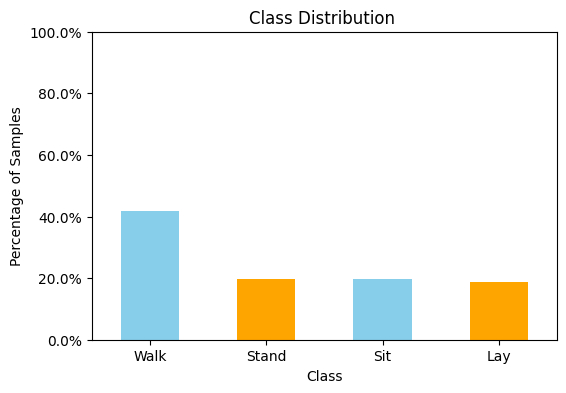

In [ ]:


# Check class imbalance
class_counts = df['Class'].value_counts()
total = class_counts.sum()

# Convert counts to percentages
class_percentages = (class_counts / total) * 100

print("Class distribution (%):\n", class_percentages)
imbalance_ratio = class_counts.min() / class_counts.max()
print(f"Class imbalance ratio (minority/majority): {imbalance_ratio:.3f}")

# Visualization
plt.figure(figsize=(6, 4))
class_percentages.plot(kind='bar', color=['skyblue', 'orange'])
plt.title('Class Distribution ')
plt.xlabel('Class')
plt.ylabel('Percentage of Samples')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
plt.show()

In [ ]:
mapping = {
    'Stand': 0,
    'Walk': 1,
    'Sit': 2,
    'Lay': 3
}

df['Class_encoded'] = df['Class'].map(mapping)

# Now check if any NaNs remain
if df['Class_encoded'].isna().any():
    print("Unmapped class names:", df.loc[df['Class_encoded'].isna(), 'Class'].unique())

print(df[['Class', 'Class_encoded']].head())

   Class  Class_encoded
0  Stand              0
1  Stand              0
2  Stand              0
3  Stand              0
4  Stand              0


In [ ]:
df.drop(columns=['Class'], inplace=True)

In [ ]:
label_col = 'Class_encoded'

X = df.drop(columns=[label_col])
y = df[label_col]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data only
scaler.fit(X_train)

# Transform both training and test data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

1D CNN

In [ ]:
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

# ✅ FIX INPUT SHAPE (MAIN SOLUTION)
X_train_cnn = np.array(X_train_cnn)

# Remove all extra dimensions (important)
X_train_cnn = np.squeeze(X_train_cnn)

# Ensure it becomes 3D: (samples, timesteps, 1)
if len(X_train_cnn.shape) == 2:
    X_train_cnn = np.expand_dims(X_train_cnn, axis=-1)

print("X_train_cnn shape:", X_train_cnn.shape)

input_shape = (X_train_cnn.shape[1], 1)

# ✅ Correct num_classes safely
y_train = np.array(y_train).reshape(-1,)
num_classes = len(np.unique(y_train))

inputs = layers.Input(shape=input_shape)

# 1D CNN
x = layers.Conv1D(32, 3, padding='same', activation='relu')(inputs)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(64, 3, padding='same', activation='relu')(x)
x = layers.MaxPooling1D(2)(x)

x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
x = layers.MaxPooling1D(2)(x)

# Flatten
x = layers.Flatten()(x)

# Dense layers
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)

# Output
outputs = layers.Dense(num_classes, activation="softmax")(x)

# Model
cnn_model = tf.keras.Model(inputs, outputs)

cnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

cnn_model.summary()

# Train
history = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=50,
    batch_size=8,
    #batch_size=16,
    #batch_size=32,
    validation_split=0.2,
    shuffle=True
)

X_train_cnn shape: (360, 133, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 133, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 133, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 66, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 66, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 33, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 33, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301,828 (1.15 MB)

 Trainable params: 301,828 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5590 - loss: 0.8872 - val_accuracy: 0.5556 - val_loss: 0.7522
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6146 - loss: 0.7090 - val_accuracy: 0.6111 - val_loss: 0.6816
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7083 - loss: 0.6143 - val_accuracy: 0.7639 - val_loss: 0.6340
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6979 - loss: 0.5924 - val_accuracy: 0.9167 - val_loss: 0.4591
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8056 - loss: 0.4666 - val_accuracy: 0.8889 - val_loss: 0.4229
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8819 - loss: 0.3700 - val_accuracy: 0.8472 - val_loss: 0.3986
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8785 - loss: 0.2863 - val_accuracy: 0.8611 - val_loss: 0.4613
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8993 - loss: 0.3174 - val_accuracy: 0.8889 - v

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np

# Predict
y_pred_probs = cnn_model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Core 4 Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("🔹 Accuracy :", accuracy)
print("🔹 Precision:", precision)
print("🔹 Recall   :", recall)
print("🔹 F1 Score :", f1)

# ✅ Detailed report (per class)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ✅ Confusion Matrix
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
🔹 Accuracy : 0.9444444444444444
🔹 Precision: 0.9453947368421053
🔹 Recall   : 0.9444444444444444
🔹 F1 Score : 0.943754538852578

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.83      0.88        18
           1       1.00      1.00      1.00        38
           2       0.88      0.88      0.88        17
           3       0.89      1.00      0.94        17

    accuracy                           0.94        90
   macro avg       0.93      0.93      0.93        90
weighted avg       0.95      0.94      0.94        90

Confusion Matrix:

[[15  0  2  1]
 [ 0 38  0  0]
 [ 1  0 15  1]
 [ 0  0  0 17]]


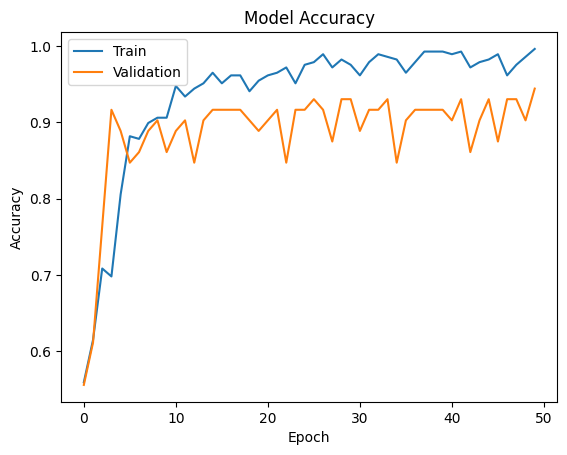

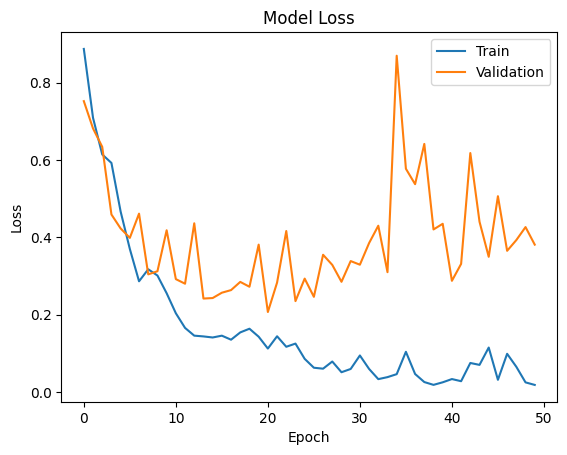

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

LSTM



In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

# ✅ FIX INPUT SHAPE PROPERLY
X_train_lstm = np.array(X_train_cnn)

# Remove extra dimensions
X_train_lstm = np.squeeze(X_train_lstm)

# Ensure 3D shape for LSTM: (samples, timesteps, features)
if len(X_train_lstm.shape) == 2:
    X_train_lstm = np.expand_dims(X_train_lstm, axis=-1)

print("X_train_lstm shape:", X_train_lstm.shape)

input_shape = (X_train_lstm.shape[1], 1)

# ✅ Fix labels
y_train = np.array(y_train).reshape(-1,)
num_classes = len(np.unique(y_train))

inputs = layers.Input(shape=input_shape)

# LSTM Layers
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(inputs)
x = layers.BatchNormalization()(x)

x = layers.Bidirectional(layers.LSTM(32))(x)
x = layers.BatchNormalization()(x)

# Dense layers
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.4)(x)

# Output
outputs = layers.Dense(num_classes, activation="softmax")(x)

# Model
lstm_model = tf.keras.Model(inputs, outputs)

lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

lstm_model.summary()

# ✅ Train (NO CALLBACKS)
history = lstm_model.fit(
    X_train_lstm,
    y_train,
    epochs=50,
    batch_size=8,
    #batch_size=16,
    #batch_size=32,
    validation_split=0.2,
    shuffle=True
)

X_train_lstm shape: (360, 133, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 133, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 133, 128)       │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 133, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,612 (361.77 KB)

 Trainable params: 92,228 (360.27 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 164ms/step - accuracy: 0.5417 - loss: 0.9734 - val_accuracy: 0.5833 - val_loss: 1.1803
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.5868 - loss: 0.9005 - val_accuracy: 0.7083 - val_loss: 1.0768
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 0.6597 - loss: 0.6954 - val_accuracy: 0.7083 - val_loss: 0.9760
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.6979 - loss: 0.6833 - val_accuracy: 0.7083 - val_loss: 0.8632
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.6979 - loss: 0.6240 - val_accuracy: 0.7778 - val_loss: 0.7809
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.7153 - loss: 0.6235 - val_accuracy: 0.6944 - val_loss: 0.7640
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.7431 - loss: 0.5821 - val_accuracy: 0.7917 - val_loss: 0.6870
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.7639 - loss: 0.5704 - val_accuracy: 0

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import numpy as np

# ✅ Prepare test data (IMPORTANT: reshape like train)
X_test_lstm = np.expand_dims(X_test_cnn.squeeze(), axis=-1)

# Predict
y_pred_probs = lstm_model.predict(X_test_lstm)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ Core metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("🔹 Accuracy :", round(accuracy, 4))
print("🔹 Precision:", round(precision, 4))
print("🔹 Recall   :", round(recall, 4))
print("🔹 F1 Score :", round(f1, 4))

# ✅ Detailed report
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

# ✅ Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 358ms/step
🔹 Accuracy : 0.8111
🔹 Precision: 0.8218
🔹 Recall   : 0.8111
🔹 F1 Score : 0.8022

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.89      0.76        18
           1       1.00      1.00      1.00        38
           2       0.63      0.71      0.67        17
           3       0.78      0.41      0.54        17

    accuracy                           0.81        90
   macro avg       0.77      0.75      0.74        90
weighted avg       0.82      0.81      0.80        90

Confusion Matrix:
 [[16  0  1  1]
 [ 0 38  0  0]
 [ 4  0 12  1]
 [ 4  0  6  7]]


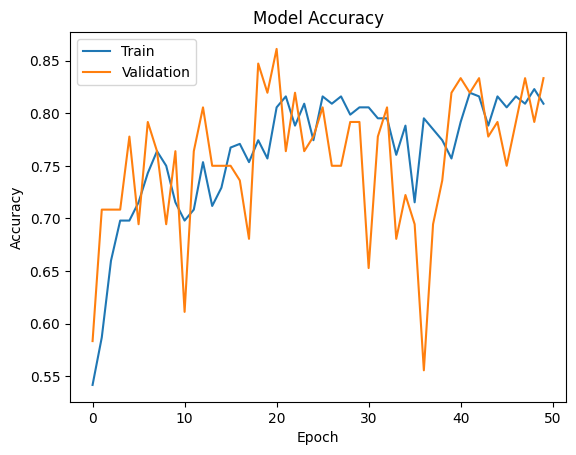

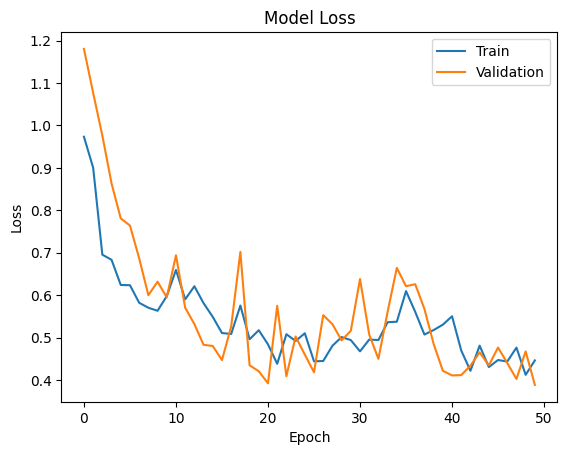

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss plot
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()